# 03. Popularity 기반 예측

"지난 3주간 인기 있던 repo가 다음 1주에도 인기 있을까?"

가장 단순한 추천 baseline — **과거 인기도로 미래를 예측**합니다.

- **Train**: 2026-02-15 ~ 2026-03-07 (3주)
- **Test**: 2026-03-08 ~ 2026-03-14 (1주)

## 1. 데이터 로드 & Train/Test Split

In [1]:
from datetime import date
from pathlib import Path

from ghrec.recommend import load_period, popularity_scores, top_n_repos

OUTPUT_DIR = Path("../../data/daily_agg")

TRAIN_START, TRAIN_END = date(2026, 2, 15), date(2026, 3, 7)
TEST_START, TEST_END = date(2026, 3, 8), date(2026, 3, 14)

train_df = load_period(OUTPUT_DIR, TRAIN_START, TRAIN_END)
test_df = load_period(OUTPUT_DIR, TEST_START, TEST_END)

print(f"Train: {len(train_df):,} rows  ({TRAIN_START} ~ {TRAIN_END})")
print(f"Test:  {len(test_df):,} rows  ({TEST_START} ~ {TEST_END})")
print(f"Event types: {sorted(train_df['type'].unique())}")

Train: 29,008,179 rows  (2026-02-15 ~ 2026-03-07)
Test:  9,812,145 rows  (2026-03-08 ~ 2026-03-14)


Event types: ['CommitCommentEvent', 'CreateEvent', 'DeleteEvent', 'DiscussionEvent', 'ForkEvent', 'GollumEvent', 'IssueCommentEvent', 'IssuesEvent', 'MemberEvent', 'PublicEvent', 'PullRequestEvent', 'PullRequestReviewCommentEvent', 'PullRequestReviewEvent', 'PushEvent', 'ReleaseEvent', 'WatchEvent']


## 2. 가중치 정의 & Train 기간 인기도 계산

In [2]:
WEIGHTS = {
    "WatchEvent": 1.0,
    "ForkEvent": 2.0,
    "IssuesEvent": 0.5,
    "PullRequestEvent": 3.0,
    "IssueCommentEvent": 0.3,
    "PushEvent": 0.2,
}

train_scores = popularity_scores(train_df, WEIGHTS)
print(f"Total scored repos: {len(train_scores):,}")
print(f"\nTop 10 (train period):")
print(top_n_repos(train_scores, 10))

Total scored repos: 8,146,556

Top 10 (train period):
repo_id
1103012935    99844.0
678894831     54822.4
4542716       41661.8
1156956890    40391.3
197275551     38292.8
1076470140    36353.7
1128494107    35221.1
1099385184    31431.4
1156518861    27315.5
1156607103    23477.0
Name: score, dtype: Float64


## 3. 예측 vs Ground Truth

Train 기간 상위 repo → **예측(predicted)**  
Test 기간 상위 repo → **정답(actual)**

In [3]:
MAX_K = 50  # 평가할 최대 K (여유 있게)

test_scores = popularity_scores(test_df, WEIGHTS)

predicted = top_n_repos(train_scores, MAX_K).index.tolist()
actual = top_n_repos(test_scores, MAX_K).index.tolist()

overlap = set(predicted[:30]) & set(actual[:30])
print(f"Top-30 예측 중 실제 Top-30에도 있는 repo: {len(overlap)}/30")
print(f"겹치는 비율: {len(overlap)/30:.1%}")

Top-30 예측 중 실제 Top-30에도 있는 repo: 14/30
겹치는 비율: 46.7%


## 4. 정량 평가 — K별 메트릭

In [4]:
import pandas as pd

from ghrec.evaluate import evaluate_all

# repo별 event count pivot (diversity 계산용)
repo_event_counts = (
    train_df.groupby(["repo_id", "type"], observed=True)["cnt"]
    .sum()
    .reset_index()
    .pivot_table(index="repo_id", columns="type", values="cnt", fill_value=0)
)
total_repos = len(repo_event_counts)

K_VALUES = [10, 20, 30]
results = []
for k in K_VALUES:
    metrics = evaluate_all(predicted, actual, k, repo_event_counts, total_repos)
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("k")
print("Popularity Baseline 평가 결과:")
print(results_df.round(4).to_string())

Popularity Baseline 평가 결과:
    precision@k  ndcg@k  diversity_entropy  coverage
k                                                   
10       0.8000  0.8390             1.9320       0.0
20       0.6500  0.7218             1.5460       0.0
30       0.4667  0.5809             1.4674       0.0


## 5. 가중치 실험

가중치를 바꾸면 결과가 어떻게 달라질까?

In [5]:
WEIGHT_CONFIGS = {
    "star_only": {"WatchEvent": 1.0},
    "engagement": {
        "WatchEvent": 1.0,
        "ForkEvent": 2.0,
        "IssuesEvent": 0.5,
        "PullRequestEvent": 3.0,
        "IssueCommentEvent": 0.3,
        "PushEvent": 0.2,
    },
    "dev_activity": {
        "PushEvent": 1.0,
        "PullRequestEvent": 2.0,
        "IssuesEvent": 1.0,
        "IssueCommentEvent": 0.5,
    },
    "uniform": {
        "WatchEvent": 1.0,
        "ForkEvent": 1.0,
        "IssuesEvent": 1.0,
        "PullRequestEvent": 1.0,
        "IssueCommentEvent": 1.0,
        "PushEvent": 1.0,
    },
}

K = 30
comparison = []
for name, weights in WEIGHT_CONFIGS.items():
    scores = popularity_scores(train_df, weights)
    pred = top_n_repos(scores, MAX_K).index.tolist()
    metrics = evaluate_all(pred, actual, K, repo_event_counts, total_repos)
    metrics["config"] = name
    comparison.append(metrics)

comp_df = pd.DataFrame(comparison).set_index("config")[
    ["precision@k", "ndcg@k", "diversity_entropy"]
]
print(f"가중치 실험 결과 (K={K}):")
print(comp_df.round(4).to_string())

가중치 실험 결과 (K=30):
              precision@k  ndcg@k  diversity_entropy
config                                              
star_only          0.0333  0.1092             2.2355
engagement         0.4667  0.5809             1.4674
dev_activity       0.3667  0.4659             0.6762
uniform            0.3667  0.4655             0.6762


## 6. 시각화

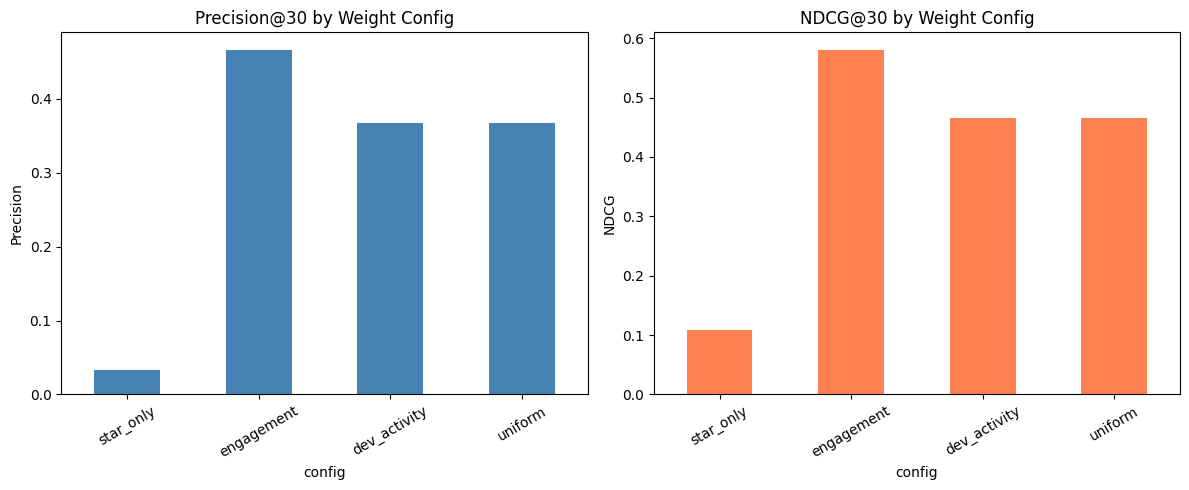

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Precision@K by config
comp_df["precision@k"].plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title(f"Precision@{K} by Weight Config")
axes[0].set_ylabel("Precision")
axes[0].tick_params(axis="x", rotation=30)

# NDCG@K by config
comp_df["ndcg@k"].plot.bar(ax=axes[1], color="coral")
axes[1].set_title(f"NDCG@{K} by Weight Config")
axes[1].set_ylabel("NDCG")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 7. 한계 & 다음 단계

**Popularity baseline의 한계:**
- **개인화 없음** — 모든 사용자에게 같은 Top-N을 추천
- **Diversity 낮음** — 이미 유명한 repo만 반복 추천 (filter bubble)
- **Cold start** — 새로 뜨는 repo를 잡아내지 못함
- **시간 가중 없음** — 3주 전 이벤트나 어제 이벤트나 동일 취급

**다음 단계:**
1. **repo 메타데이터** 수집 → 예측 결과를 해석 가능하게 (04번 노트북)
2. **ML 모델** 도입 → 유저별 개인화, feature 기반 예측